In [43]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [44]:
DT = 1
Q0 = 17921.57581 

In [45]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
display(data)

,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415552,15.9,1.4,2404.0,2.588773,6.969502,0.494206,-2.285347,3.283184,-0.694411,247,-0.020117,-0.000300,0.064722
415553,15.9,1.4,2405.0,2.568657,6.969502,0.493907,-2.285347,3.281990,-0.713334,247,-0.020923,-0.000300,0.064333
415554,15.9,1.4,2406.0,2.547734,6.969502,0.493607,-2.285347,3.280796,-0.733063,247,-0.021729,-0.000300,0.063944
415555,15.9,1.4,2407.0,2.526005,6.969502,0.493307,-2.285347,3.279602,-0.753597,247,-0.021729,-0.000300,0.063556


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [46]:
# Batch data
feature_cols = ['I', 'u', 'Ue', 'soc']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([248, 7049, 4])  (padded, use mask for loss)
mask      : torch.Size([248, 7049])


In [47]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//2, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//2, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


In [48]:
first_rx = data.groupby('u')['F'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
print(k.values[0])

def R0_func(u, I):
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

def Mech_box(Fs, u, k=k.values[0]):
    """ F = Fs_NN(SoC) - k * delta_u """
    return Fs - k * u

def step(Fs, dFs, dt):
    return Fs + dt * dFs

0.5316441632537718


In [ ]:
import torch.nn.functional as TF

def masked_mse(y_pred, y_target, mask):
    '''
    y_pred, y_true : (B, T_max)
    mask           : (B, T_max)      True where valid
    '''
    sq_err = (y_pred - y_target) ** 2
    return sq_err[mask].mean()  

class NeuralODE(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        # self.fs_dot_net = nn.Sequential(     
        #     nn.Linear(5, hidden_size),   # [Fs_t, I_t, u_t, U_eq_t, soc]
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, hidden_size),
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, 1)   # output: dFs/dt
        # )
        # self.r0_net = nn.Sequential(
        #     nn.Linear(4, hidden_size),  # [I_t, u_t, U_eq_t, soc_t]
        #     nn.ReLU(),
        #     nn.Linear(hidden_size, 1)
        # )
        self.rc_dot_net = nn.Sequential(
            nn.Linear(5, hidden_size),  # [V_rc_t, I_t, u_t, U_eq_t, soc_t]
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    # def r_forward(self, x_b):
    #     R0_raw = self.r0_net(x_b)
    #     R0 = TF.softplus(R0_raw).squeeze(-1)  # Ensure positivity and (B, T)
    #     return R0

    def rc_rollout(self, x_b, V_rc0, mask=None):
        '''
        x_b   : (B, T, 4)  (I, u, U_eq, soc)
        V_rc0 : (B,)        initial RC voltage
        mask  : (B, T) bool — True where data is valid (not padding)
        '''
        V_rc = V_rc0
        V_rc_preds = []
        T = x_b.shape[1]

        for t in range(T):
            ode_input = torch.cat([V_rc.unsqueeze(-1), x_b[:, t, :]], dim=-1)  # (B, 5)     Fed with predicted value, not teacher forcing
            dV_rc = self.rc_dot_net(ode_input).squeeze(-1)                         # (B,)
            dV_rc = torch.clamp(dV_rc, -20.0, 20.0)                             # prevent explosion

            V_rc_new = step(V_rc, dV_rc, dt=DT)     # Compute new V_rc based on ODE step

            # On padded timesteps: freeze the state (don't let zeros corrupt V_rc)
            if mask is not None:
                valid = mask[:, t]                                   # (B,) bool
                V_rc = torch.where(valid, V_rc_new, V_rc.detach())   # If valid return new, else keep old (no grad)
            else:
                V_rc = V_rc_new

            V_rc_preds.append(V_rc)

        return torch.stack(V_rc_preds, dim=1)   # (B, T)
    

    # def f_rollout(self, x_b, Fs0):
    #     '''
    #     x_b : (B, T, 4)  (I, u, U_eq, soc)
    #     Fs0 : (B,)       initial swelling force for each trajectory
    #     '''
    #     Fs_preds = []
    #     T = x_b.shape[1]

    #     # Rollout
    #     for t in range(T):
    #         # print(f'{t}/{T}', end='\r')
    #         ode_input = torch.cat([Fs0.unsqueeze(-1), x_b[:, t, :]], dim=-1)  # (B, Cx+1)
    #         dF = self.fs_dot_net(ode_input).squeeze(-1)     # (B,)
            
    #         Fs0 = step(Fs0, dF, dt=DT)
    #         Fs_preds.append(Fs0)
            
    #     return torch.stack(Fs_preds, dim=1)
    

    def tf_loss_eta_direct(self, x_b, y_b, mask_b):
        '''
        Teacher forcing where the ODE state IS eta.
        deta/dt is predicted; teacher signal = finite difference of true eta.
        No R0 needed at all.
        '''
        eta_true = y_b[:, :, 2]   # (B, T)  — adjust sign to match your convention

        # Target derivative from data
        d_eta_target = (eta_true[:, 1:] - eta_true[:, :-1]) / DT    # (B, T-1)   future eta - current eta

        # ODE input: [eta_true[t], I[t], u[t], U_eq[t], soc[t]]
        ode_input  = torch.cat([eta_true[:, :-1].unsqueeze(-1), x_b[:, :-1, :]], dim=-1)   # (B, T-1, 5) fed with true eta for teacher forcing
        d_eta_pred = self.rc_dot_net(ode_input).squeeze(-1)         # (B, T-1)

        return masked_mse(d_eta_pred, d_eta_target, mask_b[:, 1:])
    
    def tf_loss_with_scheduled_sampling(self, x_b, y_b, mask_b, teacher_ratio=1.0):
        """
        teacher_ratio=1.0 - pure teacher forcing
        teacher_ratio=0.0 - pure rollout (self-fed)
        Anneal teacher_ratio toward 0 over training.
        """
        eta_true = y_b[:, :, 2]          # (B, T)
        B, T, _ = x_b.shape

        state = eta_true[:, 0]            # always start from true initial state
        preds = []

        for t in range(T - 1):
            ode_input  = torch.cat([state.unsqueeze(-1), x_b[:, t, :]], dim=-1)  # (B, 5)
            d_eta_raw = self.rc_dot_net(ode_input).squeeze(-1)                   # (B,)
            d_eta_pred = - TF.softplus(d_eta_raw)                                # Ensure negativity (discharge) (B, T-1)
            eta_next_pred = state + d_eta_pred * DT                               # Euler step

            # Scheduled sampling: mix true and predicted next state
            use_true = torch.rand(B, device=x_b.device) < teacher_ratio           # (B,) bool
            state    = torch.where(use_true, eta_true[:, t + 1], eta_next_pred)

            preds.append(eta_next_pred)   # always record the prediction, not the mixed state

        eta_pred_seq = torch.stack(preds, dim=1)                                  # (B, T-1)
        d_eta_target = (eta_true[:, 1:] - eta_true[:, :-1]) / DT                 # (B, T-1)

        return masked_mse(eta_pred_seq, eta_true[:, 1:], mask_b[:, 1:])           # predict next eta directly
    
    
    def forward(self, x_b, V_rc0, Fs0, mask=None, dt=2.0):
        I = x_b[:, :, 0]    # (B, T)
        u = x_b[:, :, 1]    # (B, T)
        U_eq = x_b[:, :, 2] # (B, T)

        ''' Rollout-based forward pass '''
        # R0 = self.r_forward(x_b)
        # V_rc = self.rc_rollout(x_b, V_rc0, mask)
        # Fs = self.f_rollout(x_b, F0)

        # eta_pred = V_rc # + R0 * I     # (B, T) Overpotential
        # V_pred   = U_eq - eta_pred   # (B, T)
        # F_pred = Mech_box(Fs, u)

        ''' Teacher forcing forward pass '''
        
        V_rc     = self.rc_rollout(x_b, V_rc0, mask)  # (B, T)
        eta_pred = V_rc
        V_pred   = U_eq - eta_pred

        return V_pred, eta_pred#, F_pred

model = NeuralODE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [50]:
# def training(epochs=30):
#     history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

#     warmup_eps = epochs
#     tot_time = 0.

#     model.train()
#     for ep in range(epochs):
#         start_t = time.perf_counter()    
#         ep_loss = 0.0

#         for x_b, y_b, mask_b in loader_train:   # Start: one trajectory (B=1, T, C) at a time

#             Fs0 = torch.zeros(x_b.shape[0])     # (B,) initial swelling force
#             V_rc0 = torch.zeros(x_b.shape[0])   # (B,) initial swelling voltage

#             if ep < warmup_eps:
#                 # Teacher forcing loss for first few epochs to stabilize training
#                 loss = model.tf_loss_eta_direct(x_b, y_b, mask_b)
#             else:
#                 loss_tf = model.tf_loss_eta_direct(x_b, y_b, mask_b)
#                 V, eta  = model(x_b, V_rc0, Fs0, mask_b) # (B, T)
#                 loss_roll = masked_mse(eta, y_b[:,:,2], mask_b)
#                 loss = 0.5*loss_tf + 0.5*loss_roll

#             # V, eta = model(x_b, V_rc0, Fs0, mask_b) # (B, T)
#             # loss_V = masked_mse(eta, y_b[:,:,2], mask_b) 
#             # loss_F = TF.mse_loss(F, y_b[:,:,1])

#             # Backprop
#             optimizer.zero_grad()
#             loss.backward()
#             # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent explosion
#             optimizer.step()
#             ep_loss += loss.item()
            
#         ep_loss /= len(loader_train)

#         history["loss"].append(ep_loss)
#         # history["V_loss"].append(loss_V.item() / len(loader_train))
#         # history["F_loss"].append(loss_F.item() / len(loader_train))
#         end_t = time.perf_counter()
#         history["time per ep"].append(end_t - start_t)   
        
#         tot_time += end_t - start_t
       
#         if ep == 0:
#             print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

#         if tot_time > 10*60:
#             print("Early stopping: Total training time exceeded 10 minutes.")
#             break
#         print(f"Epoch {ep+1} | loss {ep_loss:.2e} | time {end_t - start_t:.2f}s")

#     return history


def training(epochs):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}
    tot_time = 0.
    model.train()
    for ep in range(epochs):
        start_t      = time.perf_counter()
        ep_loss      = 0.0
        teacher_ratio = max(1.0, 1.0 - ep / epochs)   # linear decay 1 to 0

        for x_b, y_b, mask_b in loader_train:
            loss = model.tf_loss_with_scheduled_sampling(x_b, y_b, mask_b, teacher_ratio)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()            

        ep_loss /= len(loader_train)
        history["loss"].append(ep_loss)

        end_t     = time.perf_counter()
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        if tot_time > 10 * 60:
            print("Early stopping.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | teacher_ratio {teacher_ratio:.2f} | time {end_t-start_t:.2f}s")

    return history

In [51]:
history = training(epochs=20)

ETA: 1.33 min
Epoch 1 | loss 1.04e-01 | teacher_ratio 1.00 | time 3.98s
Epoch 2 | loss 1.11e-01 | teacher_ratio 1.00 | time 4.05s
Epoch 3 | loss 2.04e-02 | teacher_ratio 1.00 | time 3.47s
Epoch 4 | loss 1.11e-02 | teacher_ratio 1.00 | time 3.55s
Epoch 5 | loss 1.61e-02 | teacher_ratio 1.00 | time 3.45s
Epoch 6 | loss 4.76e-03 | teacher_ratio 1.00 | time 3.37s
Epoch 7 | loss 1.02e-02 | teacher_ratio 1.00 | time 3.59s
Epoch 8 | loss 2.86e-03 | teacher_ratio 1.00 | time 3.35s
Epoch 9 | loss 4.16e-03 | teacher_ratio 1.00 | time 3.36s
Epoch 10 | loss 4.28e-03 | teacher_ratio 1.00 | time 3.58s
Epoch 11 | loss 1.62e-03 | teacher_ratio 1.00 | time 3.46s
Epoch 12 | loss 3.24e-03 | teacher_ratio 1.00 | time 3.51s
Epoch 13 | loss 1.17e-03 | teacher_ratio 1.00 | time 3.70s
Epoch 14 | loss 1.76e-03 | teacher_ratio 1.00 | time 3.58s
Epoch 15 | loss 1.39e-03 | teacher_ratio 1.00 | time 3.34s
Epoch 16 | loss 7.49e-04 | teacher_ratio 1.00 | time 3.39s
Epoch 17 | loss 1.23e-03 | teacher_ratio 1.00 | tim

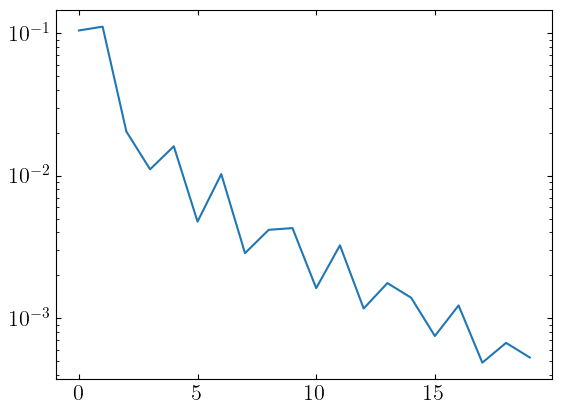

In [52]:
plt.semilogy(history["loss"], label="Total Loss")

Text(0.5, 0, 'Time step')

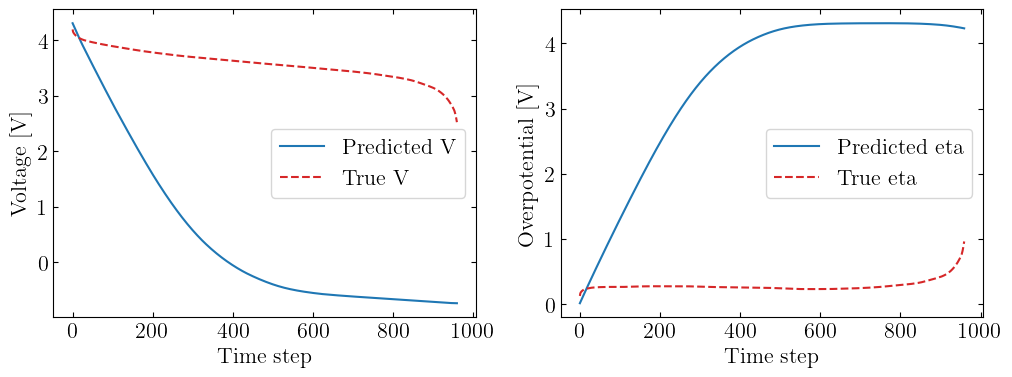

In [53]:
def evaluate(model, x_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:, :, 0]    # (B, T)
        U_eq = x_test[:, :, 2] # (B, T)

        B = x_test.shape[0]
        Fs0 = torch.zeros(B)     # (B,) initial swelling force for each trajectory
        V_rc0 = torch.zeros(B)

        # R0 = model.r_forward(x_test)
        V_pred, eta_pred = model(x_test, V_rc0, Fs0, mask_test)  # (B, T)
        

        # V_pred = model(x_test, Fs0)  # (B, T)  # Using forward for V_pred directly
    
    return V_pred.detach().numpy(), eta_pred.detach().numpy()



V_pred, eta_pred = evaluate(model, X_test)

idx = 2
t_max = mask_test[idx].sum()
t_len = np.linspace(0, t_max-1, t_max)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(t_len, V_pred[idx, :t_max], color=colors[0], label="Predicted V")
axs[0].plot(t_len, Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
axs[0].legend()
axs[0].set_ylabel("Voltage [V]")
axs[0].set_xlabel("Time step")
axs[1].plot(t_len, eta_pred[idx, :t_max], color=colors[0], label="Predicted eta")
axs[1].plot(t_len, - Y_test[idx, :t_max, 2], linestyle='--', color=colors[1], label="True eta")
axs[1].legend()
axs[1].set_ylabel("Overpotential [V]")
axs[1].set_xlabel("Time step")
# axs[1].plot(t_len, 30*R0[idx, :t_max], color=colors[0], label="Predicted R")